# Notebook 04 — Dense Autoencoder

**TFG:** Detección de Anomalías de Consumo Eléctrico y Mitigación de Ataques FDI en Edge Computing

---

### Cambios v3

| Problema v2 | Solución v3 |
|---|---|
| Bottleneck=4 OK pero BatchNorm suaviza diferencias → ataque parece normal | **Sin BatchNorm** |
| MinMaxScaler sensible a outliers, comprime señal discriminante | **RobustScaler** (como NB03) |
| MSE uniforme: 3 features con señal diluidas en 14 | **MSE ponderado**: pesos por feature calibrados en val |
| val_loss oscilaba (lr=1e-3 agresivo con batch=2048) | **lr=5e-4, batch=1024** |
| Bottleneck=4 (ratio 3.5:1) | **Bottleneck=3** (ratio 4.7:1, más selectivo) |

## 0. Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, fbeta_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib, time, os, json, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print(f'TensorFlow {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'Metal GPU: {gpus[0].name}' if gpus else 'CPU mode')
print('OK')

TensorFlow 2.16.2
Metal GPU: /physical_device:GPU:0
OK


## 1. Carga de Datos Reales

In [31]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                        index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (reales UCI)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0
    rng = f'{d.index.min().date()} → {d.index.max().date()}'
    atk = f'  | {n_atk:,} ataques ({n_atk/len(d)*100:.1f}%)' if n_atk else ''
    print(f'  {nm:6s} {len(d):>10,} filas  {rng}{atk}')

DATOS CARGADOS (reales UCI)
  Train   1,300,061 filas  2006-12-16 → 2009-06-09
  Val       144,452 filas  2009-06-09 → 2009-09-20  | 7,207 ataques (5.0%)
  Test      604,999 filas  2009-09-20 → 2010-11-26  | 31,272 ataques (5.2%)


## 2. Feature Engineering (mode = `medium` + vi_res_abs, 14 features)

Mismas 14 features que v2. El cambio está en el **scoring**, no en las features.

In [32]:
def compute_features(df, mode='full'):
    '''
    Calcula features derivadas. Identical to NB02.
      base   (8):  7 sensores + VI_residual
      medium (13): + temporales + diff1
      full   (17): + physics-based
    '''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio'] = (
            df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        )
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)
    return f

# medium (13) + vi_res_abs = 14 features
X_train_df = compute_features(df_train, mode='medium')
X_val_df   = compute_features(df_val,   mode='medium')
X_test_df  = compute_features(df_test,  mode='medium')

X_train_df['vi_res_abs'] = X_train_df['VI_residual'].abs()
X_val_df['vi_res_abs']   = X_val_df['VI_residual'].abs()
X_test_df['vi_res_abs']  = X_test_df['VI_residual'].abs()

feat_names = list(X_train_df.columns)

# ── RobustScaler (v3): usa mediana/IQR, robusto a outliers ──
# MinMaxScaler comprimía/saturaba la señal discriminante.
# RobustScaler preserva la estructura de la señal sin distorsión.
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_df.values)
X_val   = scaler.transform(X_val_df.values)
X_test  = scaler.transform(X_test_df.values)

X_train = np.nan_to_num(X_train, nan=0.0)
X_val   = np.nan_to_num(X_val, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

y_val  = df_val['label'].values
y_test = df_test['label'].values
n_features = X_train.shape[1]

print(f'Features ({n_features}): {feat_names}')
print(f'Scaler: RobustScaler (mediana/IQR)')
print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}')

Features (14): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs']
Scaler: RobustScaler (mediana/IQR)
X_train: (1300061, 14)  |  X_val: (144452, 14)  |  X_test: (604999, 14)


## 3. Arquitectura

**Sin BatchNorm** (v3): BatchNorm normaliza activaciones durante inference,
reduciendo la diferencia entre inputs normales y anómalos. En classification
esto es deseable; en anomaly detection es **contraproducente** — queremos que
los ataques produzcan activaciones diferentes.

**Bottleneck = 3** (ratio 14:3 = 4.7:1): compresión más agresiva que v2 (4).
Fuerza al AE a ser más selectivo en qué información preservar.

Arquitectura: 14 → 32 → 16 → **3** → 16 → 32 → 14

In [33]:
def build_autoencoder(n_features, bottleneck=3):
    inp = Input(shape=(n_features,), name='input')

    # Encoder (sin BatchNorm)
    x = Dense(32, activation='relu', name='enc1')(inp)
    x = Dense(16, activation='relu', name='enc2')(x)
    encoded = Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # Decoder (sin BatchNorm)
    x = Dense(16, activation='relu', name='dec1')(encoded)
    x = Dense(32, activation='relu', name='dec2')(x)
    decoded = Dense(n_features, activation='linear', name='output')(x)

    model = Model(inp, decoded, name='dense_autoencoder')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4), loss='mse')
    return model

ae = build_autoencoder(n_features, bottleneck=3)
ae.summary()
print(f'\nParametros entrenables: {ae.count_params():,}')
print(f'Ratio compresion: {n_features}:3 = {n_features/3:.1f}:1')

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Dense)                    │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Dense)                    │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec1 (Dense)                    │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec2 (Dense)                    │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,129 (8.32 KB)

 Trainable params: 2,129 (8.32 KB)

 Non-trainable params: 0 (0.00 B)


Parametros entrenables: 2,129
Ratio compresion: 14:3 = 4.7:1


## 4. Entrenamiento

In [34]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history = ae.fit(
    X_train, X_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0
print(f'\nEntrenamiento: {t_train:.1f} s | {len(history.history["loss"])} epocas')

Epoch 1/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - loss: 5.6840 - val_loss: 0.8661 - learning_rate: 5.0000e-04
Epoch 2/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.8902 - val_loss: 0.9276 - learning_rate: 5.0000e-04
Epoch 3/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 71.9798 - val_loss: 1.2340 - learning_rate: 5.0000e-04
Epoch 4/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 3.5930 - val_loss: 0.8298 - learning_rate: 5.0000e-04
Epoch 5/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 4.4964 - val_loss: 0.7609 - learning_rate: 5.0000e-04
Epoch 6/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 17.2386 - val_loss: 1.9883 - learning_rate: 5.0000e-04
Epoch 7/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 40.6805 - val_loss: 0.6011 - learning_rate: 5.0000e-04
Epoch 8/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 26.7661 - val_loss: 0.5443 - learning_rate: 5.0000e-04
Epoch 9/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/s

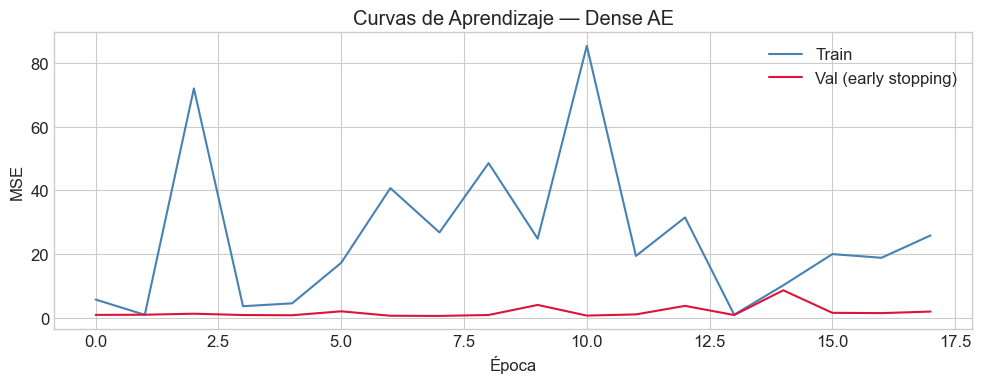

Mejor val_loss: 0.544294


In [35]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], 'steelblue', label='Train')
ax.plot(history.history['val_loss'], 'crimson', label='Val (early stopping)')
ax.set(xlabel='Época', ylabel='MSE', title='Curvas de Aprendizaje — Dense AE')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor val_loss: {min(history.history["val_loss"]):.6f}')

## 5. Calibración: MSE Ponderado + Umbral

### Por qué MSE uniforme es subóptimo

MSE = mean(Σ (x_i - x̂_i)²) pondera las 14 features por igual.
Pero solo 3-4 features llevan señal de ataque (GAP, VI_residual, vi_res_abs, Voltage).
Las otras 10 se reconstruyen bien incluso para ataques → diluyen el score.

### Solución: MSE ponderado

1. Calcular MSE **por feature** en val
2. Para cada feature, medir su **poder discriminante** (AUC-ROC individual)
3. Usar los AUC individuales como pesos → features más discriminantes pesan más
4. Calibrar umbral sobre el score ponderado

In [36]:
def calibrate_threshold(y_true, scores, beta=1.0):
    """Busca umbral que maximiza F_beta usando precision_recall_curve."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions = precisions[:-1]
    recalls    = recalls[:-1]
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))
    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]
    n = len(thresholds)
    idx = np.linspace(0, n-1, min(500, n), dtype=int)
    results_df = pd.DataFrame({
        'threshold':  thresholds[idx],
        'precision':  precisions[idx],
        'recall':     recalls[idx],
        'f1': ((2 * precisions * recalls) / (precisions + recalls + 1e-10))[idx],
        'f2': ((5 * precisions * recalls) / (4 * precisions + recalls + 1e-10))[idx],
    })
    return best_thr, fbeta[best_idx], results_df


# ── Paso 1: MSE por feature en val ──
X_val_pred = ae.predict(X_val, batch_size=4096, verbose=0)
mse_per_feature_val = (X_val - X_val_pred) ** 2  # shape: (n_val, 14)

# ── Paso 2: AUC-ROC individual por feature → pesos ──
print('Poder discriminante por feature (AUC-ROC individual):')
feature_aucs = []
for j, fname in enumerate(feat_names):
    try:
        auc_j = roc_auc_score(y_val, mse_per_feature_val[:, j])
    except ValueError:
        auc_j = 0.5
    feature_aucs.append(auc_j)
    marker = ' <<<' if auc_j > 0.60 else ''
    print(f'  {fname:30s}  AUC={auc_j:.4f}{marker}')

feature_aucs = np.array(feature_aucs)

# ── Paso 3: Pesos = AUC normalizado (features con AUC < 0.5 → peso 0) ──
weights = np.maximum(feature_aucs - 0.5, 0)  # solo features que discriminan
weights = weights / (weights.sum() + 1e-10)    # normalizar a suma=1
print()
print('Pesos normalizados:')
for j, fname in enumerate(feat_names):
    if weights[j] > 0.01:
        print(f'  {fname:30s}  w={weights[j]:.4f}')

# ── Paso 4: Score ponderado ──
scores_val = np.sum(mse_per_feature_val * weights[None, :], axis=1)

X_test_pred = ae.predict(X_test, batch_size=4096, verbose=0)
mse_per_feature_test = (X_test - X_test_pred) ** 2
scores_test = np.sum(mse_per_feature_test * weights[None, :], axis=1)

# ── Paso 5: Calibrar umbral en val ──
best_thr, best_f1, cal_df = calibrate_threshold(y_val, scores_val, beta=1.0)
_, best_f2_val, _ = calibrate_threshold(y_val, scores_val, beta=2.0)

print()
print(f'Score: MSE ponderado (weighted by per-feature AUC)')
print(f'Umbral optimo (val, F1): {best_thr:.6f}')
print(f'  F1 en val: {best_f1:.4f}')
print(f'  F2 en val: {best_f2_val:.4f}')

Poder discriminante por feature (AUC-ROC individual):
  Global_active_power             AUC=0.5204
  Global_reactive_power           AUC=0.5232
  Voltage                         AUC=0.5950
  Global_intensity                AUC=0.4956
  Sub_metering_1                  AUC=0.8319 <<<
  Sub_metering_2                  AUC=0.8375 <<<
  Sub_metering_3                  AUC=0.3934
  VI_residual                     AUC=0.9123 <<<
  hour_sin                        AUC=0.5518
  hour_cos                        AUC=0.4658
  dow_sin                         AUC=0.5138
  dow_cos                         AUC=0.5052
  gap_diff1                       AUC=0.8468 <<<
  vi_res_abs                      AUC=0.9024 <<<

Pesos normalizados:
  Global_reactive_power           w=0.0114
  Voltage                         w=0.0465
  Sub_metering_1                  w=0.1627
  Sub_metering_2                  w=0.1654
  VI_residual                     w=0.2021
  hour_sin                        w=0.0254
  gap_diff1      

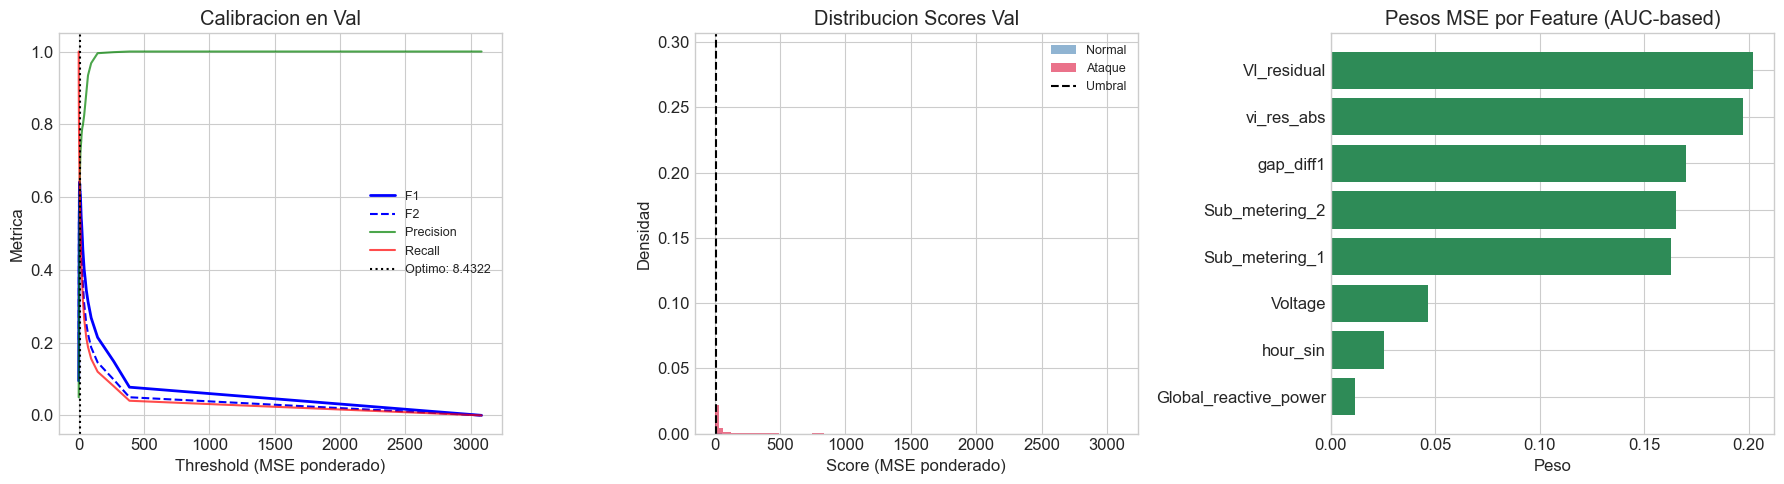

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Izq: P/R/F1/F2 vs threshold
ax = axes[0]
ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')
ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')
ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5, label='Precision', alpha=0.7)
ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5, label='Recall', alpha=0.7)
ax.axvline(best_thr, color='k', linestyle=':', lw=1.5, label=f'Optimo: {best_thr:.4f}')
ax.set(xlabel='Threshold (MSE ponderado)', ylabel='Metrica', title='Calibracion en Val')
ax.legend(fontsize=9)

# Medio: distribucion scores
ax = axes[1]
ax.hist(scores_val[y_val == 0], bins=100, alpha=0.6, color='steelblue',
        label='Normal', density=True)
ax.hist(scores_val[y_val == 1], bins=100, alpha=0.6, color='crimson',
        label='Ataque', density=True)
ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Umbral')
ax.set(xlabel='Score (MSE ponderado)', ylabel='Densidad',
       title='Distribucion Scores Val')
ax.legend(fontsize=9)

# Der: pesos por feature
ax = axes[2]
sorted_idx = np.argsort(weights)[::-1]
top_n = min(10, (weights > 0.01).sum())
top_idx = sorted_idx[:top_n]
ax.barh([feat_names[j] for j in top_idx], weights[top_idx], color='seagreen')
ax.set_xlabel('Peso')
ax.set_title('Pesos MSE por Feature (AUC-based)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Evaluacion RAW (sin post-procesamiento)

In [38]:
y_pred = (scores_test > best_thr).astype(int)

print('=' * 60)
print('MÉTRICAS — DENSE AUTOENCODER')
print('=' * 60)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Ataque']))

f1  = f1_score(y_test, y_pred)
f2  = fbeta_score(y_test, y_pred, beta=2)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

MÉTRICAS — DENSE AUTOENCODER

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98    573727
      Ataque       0.71      0.70      0.70     31272

    accuracy                           0.97    604999
   macro avg       0.85      0.84      0.84    604999
weighted avg       0.97      0.97      0.97    604999

AUC-ROC: 0.9295  |  AUC-PR: 0.7571
F1: 0.7048  |  F2: 0.7033  |  Precision: 0.7074  |  Recall: 0.7022


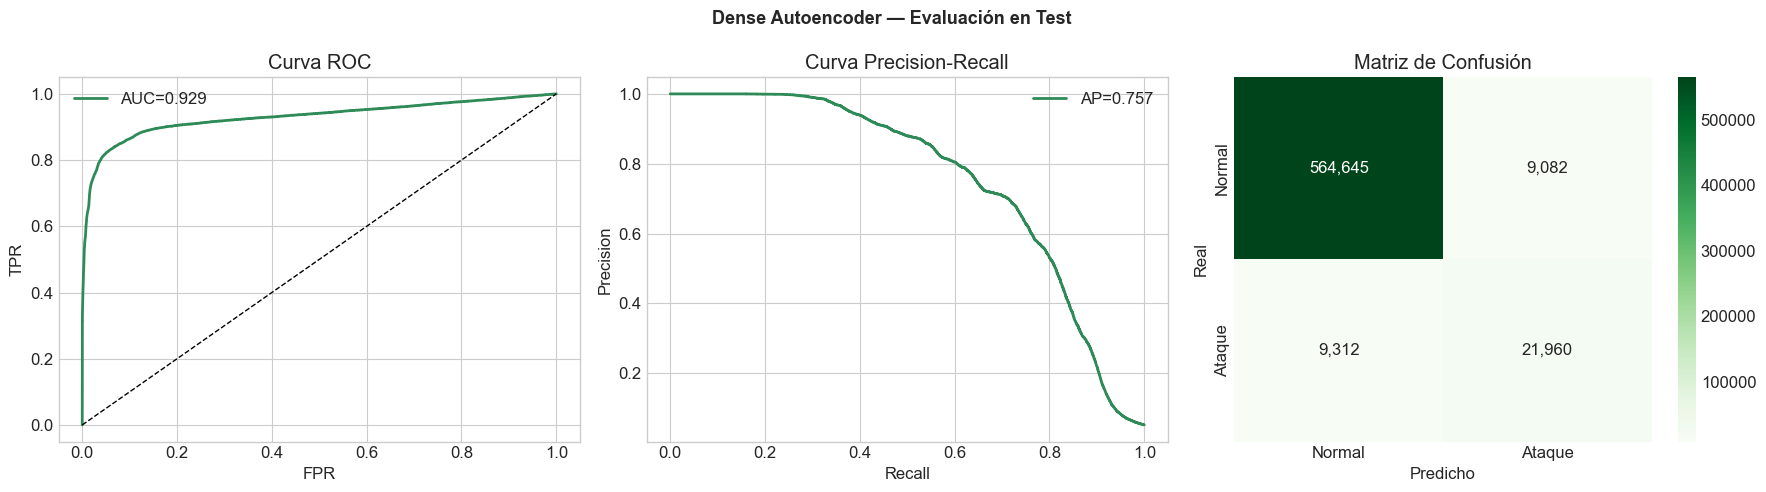

In [39]:
# ROC + PR + Matriz de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr, tpr, 'seagreen', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC')
axes[0].legend()

pr_c, rc_c, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c, pr_c, 'seagreen', lw=2, label=f'AP={auc_pr:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Curva Precision-Recall')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Greens',
            ax=axes[2], xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[2].set(xlabel='Predicho', ylabel='Real', title='Matriz de Confusión')

plt.suptitle('Dense Autoencoder — Evaluación en Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Post-procesamiento Temporal — Filtro de Votacion

In [40]:
def temporal_vote_vectorized(y_pred, W, K):
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)

y_pred_val_raw = (scores_val > best_thr).astype(int)
print(f'Raw positivos en val: {y_pred_val_raw.sum():,} ({y_pred_val_raw.mean()*100:.1f}%)')

W_candidates = [3, 5, 7, 9, 11, 15, 21, 30]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(y_pred_val_raw, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        grid_results.append({'W': W, 'K': K, 'f1': f1_sm,
                             'precision': pr_sm, 'recall': rc_sm})
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'Mejor (W,K): W={best_W}, K={best_K}')
print(f'  F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')

Raw positivos en val: 6,895 (4.8%)
Mejor (W,K): W=11, K=5
  F1=0.7052  P=0.7699  R=0.6505


In [41]:
y_pred_raw    = (scores_test > best_thr).astype(int)
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print('=' * 70)
print('COMPARACION — DENSE AE: RAW vs TEMPORAL VOTING')
print('=' * 70)
print()
print(f'  {"Metrica":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')
print('  ' + '-' * 45)
for name, raw_v, sm_v in [
    ('F1',        f1,   f1_s),
    ('F2',        f2,   f2_s),
    ('Precision',  prec,  prec_s),
    ('Recall',     rec,   rec_s),
]:
    delta = sm_v - raw_v
    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')
print()
print(f'  Filtro: W={best_W}, K={best_K}')
print()
print(classification_report(y_test, y_pred_smooth, target_names=['Normal', 'Ataque']))

COMPARACION — DENSE AE: RAW vs TEMPORAL VOTING

  Metrica             Raw   Smoothed      Delta
  ---------------------------------------------
  F1               0.7048     0.7373    +0.0324
  F2               0.7033     0.7202    +0.0170
  Precision        0.7074     0.7675    +0.0601
  Recall           0.7022     0.7093    +0.0071

  Filtro: W=11, K=5

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99    573727
      Ataque       0.77      0.71      0.74     31272

    accuracy                           0.97    604999
   macro avg       0.88      0.85      0.86    604999
weighted avg       0.97      0.97      0.97    604999



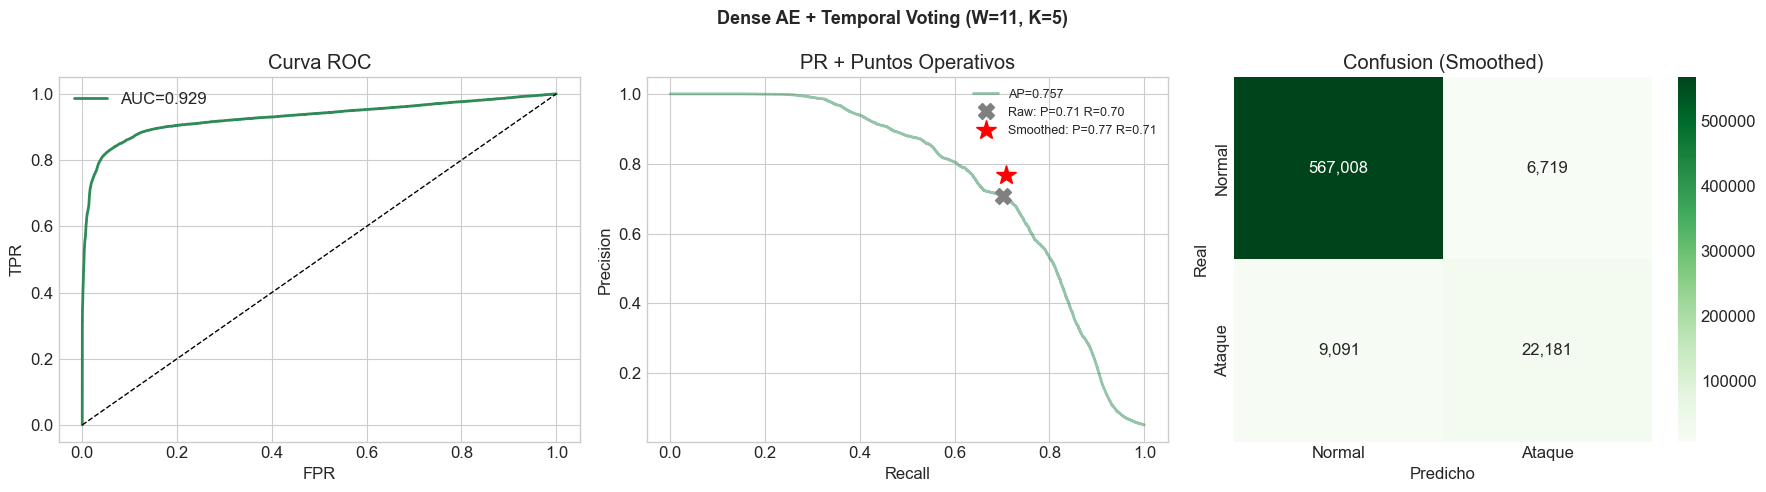

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_s, tpr_s, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr_s, tpr_s, 'seagreen', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC')
axes[0].legend()

pr_c2, rc_c2, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c2, pr_c2, 'seagreen', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)
axes[1].plot(rec, prec, 'X', color='gray', markersize=12,
             label=f'Raw: P={prec:.2f} R={rec:.2f}')
axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,
             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Puntos Operativos')
axes[1].legend(fontsize=9)

cm_s = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm_s, annot=True, fmt=',d', cmap='Greens', ax=axes[2],
            xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[2].set(xlabel='Predicho', ylabel='Real', title='Confusion (Smoothed)')
plt.suptitle(f'Dense AE + Temporal Voting (W={best_W}, K={best_K})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Recall por Tipo x Severidad (Smoothed)

In [43]:
def temporal_vote_vectorized(y_pred, W, K):
    '''Filtro de votacion causal. O(n) con cumsum.'''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)

y_pred_val_raw = (scores_val > best_thr).astype(int)
print(f'Predicciones raw en val: {y_pred_val_raw.sum():,} ({y_pred_val_raw.mean()*100:.1f}%)')

W_candidates = [3, 5, 7, 9, 11, 15, 21, 30]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(y_pred_val_raw, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        grid_results.append({'W': W, 'K': K, 'f1': f1_sm,
                             'precision': pr_sm, 'recall': rc_sm})
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'Mejor (W,K): W={best_W}, K={best_K}')
print(f'  F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')

Predicciones raw en val: 6,895 (4.8%)
Mejor (W,K): W=11, K=5
  F1=0.7052  P=0.7699  R=0.6505


## 9. Latencia de Deteccion (Smoothed)

In [44]:
def compute_detection_latency(df_preds, score_col, threshold):
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id, 'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0], 'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)

def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan
    print(f'Deteccion por episodio: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')
    if not np.isnan(med_lat):
        print(f'Latencia mediana:       {med_lat:.1f} min')
    print()
    for sev in ['low', 'medium', 'high']:
        sub = lat_df[lat_df['severity'] == sev]
        if len(sub) == 0: continue
        det = sub['detected'].mean()
        det_sub = sub[sub['detected']]
        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan
        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'
        print(f'  {sev:8s}: deteccion {det:.0%}  |  latencia mediana {lat_s}')
    return det_rate, med_lat

df_test_scored = df_test.copy()
df_test_scored['dae_pred_smooth'] = y_pred_smooth.astype(float)
lat_df = compute_detection_latency(df_test_scored, 'dae_pred_smooth', 0.5)
det_rate, med_lat = print_latency_summary(lat_df)

Deteccion por episodio: 96.6% (338/350)
Latencia mediana:       5.0 min

  low     : deteccion 90%  |  latencia mediana 10.0 min
  medium  : deteccion 99%  |  latencia mediana 4.5 min
  high    : deteccion 100%  |  latencia mediana 4.0 min


## 10. Edge Computing + Guardado

In [45]:
model_path = os.path.join(DATA_DIR, 'model_dense_autoencoder.keras')
try:
    ae.save(model_path)
except Exception:
    model_path = os.path.join(DATA_DIR, 'model_dense_autoencoder.h5')
    ae.save(model_path)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_dense_autoencoder.pkl'))

# Save weights for weighted MSE
np.save(os.path.join(DATA_DIR, 'feature_weights_dense_ae.npy'), weights)

_ = ae.predict(X_test[:100], batch_size=4096, verbose=0)
times = []
for _ in range(5):
    t0 = time.time()
    ae.predict(X_test, batch_size=4096, verbose=0)
    times.append(time.time() - t0)
ms_avg = np.mean(times) / len(X_test) * 1000

print('=' * 55)
print('EDGE COMPUTING — DENSE AE v3')
print('=' * 55)
print(f'  Parametros:    {ae.count_params():,}')
print(f'  Bottleneck:    3 (ratio {n_features}:3 = {n_features/3:.1f}:1)')
print(f'  Scoring:       MSE ponderado ({(weights>0.01).sum()} features activas)')
print(f'  Filtro:        W={best_W}, K={best_K}')
print(f'  Tamano:        {size_kb:.1f} KB')
print(f'  Latencia:      {ms_avg:.4f} ms/muestra')
print(f'  Throughput:    {1000/ms_avg:,.0f} muestras/s')
print(f'  Entrenamiento: {t_train:.1f} s')

df_out = df_test.copy()
df_out['dae_score'] = scores_test
df_out['dae_pred_raw']    = y_pred_raw
df_out['dae_pred_smooth'] = y_pred_smooth
df_out.to_csv(os.path.join(DATA_DIR, 'predictions_dense_autoencoder.csv'))
np.save(os.path.join(DATA_DIR, 'threshold_dense_ae.npy'), np.array([best_thr]))
lat_df.to_csv(os.path.join(DATA_DIR, 'latency_dense_autoencoder.csv'), index=False)

metrics = {
    'model': 'Dense Autoencoder v3 + Temporal Voting',
    'feature_mode': 'medium + vi_res_abs',
    'scoring': 'weighted_mse',
    'raw_f1': round(f1, 4), 'raw_f2': round(f2, 4),
    'raw_precision': round(prec, 4), 'raw_recall': round(rec, 4),
    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),
    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),
    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
    'threshold': round(float(best_thr), 8),
    'temporal_W': best_W, 'temporal_K': best_K,
    'model_size_kb': round(size_kb, 1), 'ms_per_sample': round(ms_avg, 4),
    'n_params': ae.count_params(), 'n_features': n_features, 'bottleneck': 3,
    'train_time_s': round(t_train, 1),
    'detection_rate': round(det_rate, 4),
    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,
    'granularity': '1 min',
    'feature_names': feat_names,
    'feature_weights': {fn: round(float(w), 4) for fn, w in zip(feat_names, weights) if w > 0.01},
}
with open(os.path.join(DATA_DIR, 'metrics_dense_autoencoder.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print()
print('Guardado en data/:')
for fn in ['predictions_dense_autoencoder.csv', 'metrics_dense_autoencoder.json',
           'model_dense_autoencoder.keras', 'scaler_dense_autoencoder.pkl',
           'threshold_dense_ae.npy', 'feature_weights_dense_ae.npy',
           'latency_dense_autoencoder.csv']:
    print(f'  * {fn}')

EDGE COMPUTING — DENSE AE v3
  Parametros:    2,129
  Bottleneck:    3 (ratio 14:3 = 4.7:1)
  Scoring:       MSE ponderado (8 features activas)
  Filtro:        W=11, K=5
  Tamano:        68.7 KB
  Latencia:      0.0006 ms/muestra
  Throughput:    1,762,961 muestras/s
  Entrenamiento: 298.9 s

Guardado en data/:
  * predictions_dense_autoencoder.csv
  * metrics_dense_autoencoder.json
  * model_dense_autoencoder.keras
  * scaler_dense_autoencoder.pkl
  * threshold_dense_ae.npy
  * feature_weights_dense_ae.npy
  * latency_dense_autoencoder.csv
